In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_validate, validation_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
X_simple = np.linspace(-3, 3, 50).reshape(-1, 1)
y_simple = X_simple ** 2 + np.random.normal(0, 1, X_simple.shape[0]).reshape(-1, 1)


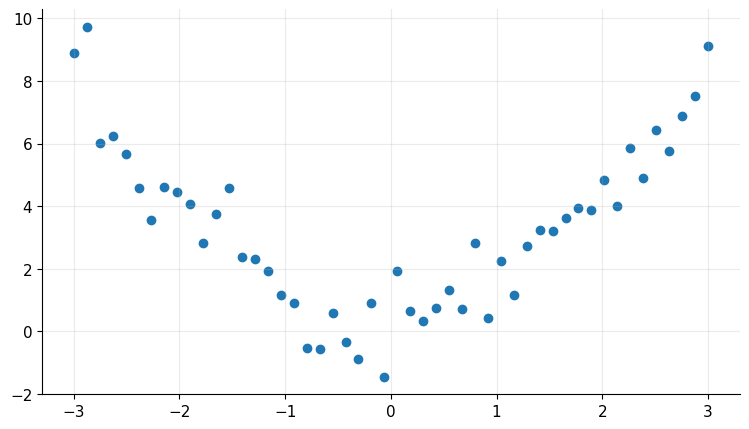

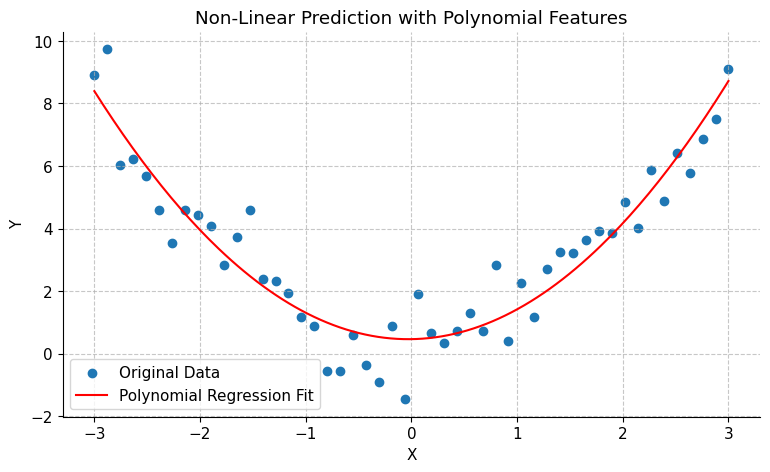

In [ ]:
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_simple)

plt.scatter(X_simple, y_simple)
plt.show()

model_simple = LinearRegression()
model_simple.fit(X_poly, y_simple)

# Generate predictions for plotting over a continuous range
x_grid_simple = np.linspace(-3, 3, 200).reshape(-1, 1)
# Transform the grid points into polynomial features using the same PolynomialFeatures object
x_grid_poly_simple = poly_features.transform(x_grid_simple)
y_pred_simple = model_simple.predict(x_grid_poly_simple)


# Plot the original data and the polynomial regression fit
plt.figure(figsize=(9, 5))
plt.scatter(X_simple, y_simple, label='Original Data')
plt.plot(x_grid_simple, y_pred_simple, color='red', label='Polynomial Regression Fit')
plt.title('Non-Linear Prediction with Polynomial Features')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def true_curve(x):
    return 2.5 + 1.4*x - 0.35 * x ** 2 + 0.04 * x ** 3

def make_curve_data(n=45, noise=3.0, x_min=-5, x_max=8, seed=42):
    local_rng = np.random.default_rng(seed)
    x = np.sort(local_rng.uniform(x_min, x_max, n))
    y_true = true_curve(x)
    y = y_true + local_rng.normal(0, noise, n)
    return x.reshape(-1, 1), y, y_true

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def polynomial_model(degree, regularizer=None, alpha=1.0):
    if regularizer is None:
        estimator = LinearRegression()
        return Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", estimator)
        ])
    if regularizer == "ridge":
        estimator = Ridge(alpha=alpha)
    elif regularizer == "lasso":
        estimator = Lasso(alpha=alpha, max_iter=20000)
    else:
        raise ValueError("regularizer must be None, 'ridge', or 'lasso'")
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

def plot_data_and_true_curve(X, y, title="Noisy curved data"):
    x_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, 400).reshape(-1, 1)
    plt.figure(figsize=(9, 5))
    plt.scatter(X[:, 0], y, color="#18202a", s=45, label="observed noisy data")
    plt.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=3, label="true underlying curve")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

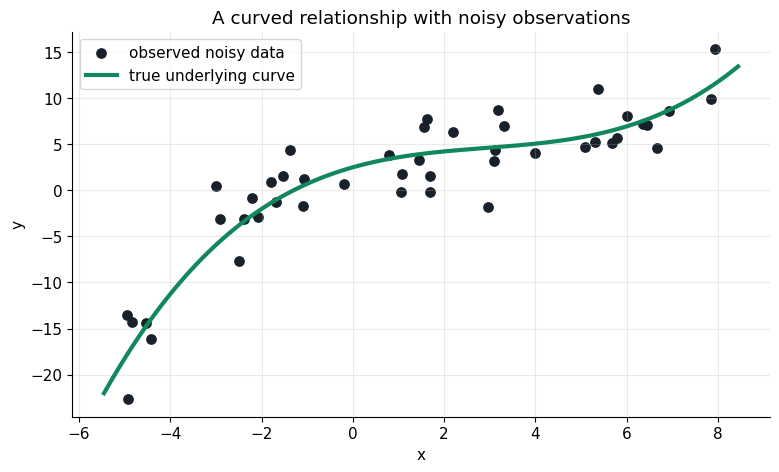

In [ ]:
X, y, y_true = make_curve_data(n=45, noise=3.2, seed=7)
plot_data_and_true_curve(X, y, title="A curved relationship with noisy observations")

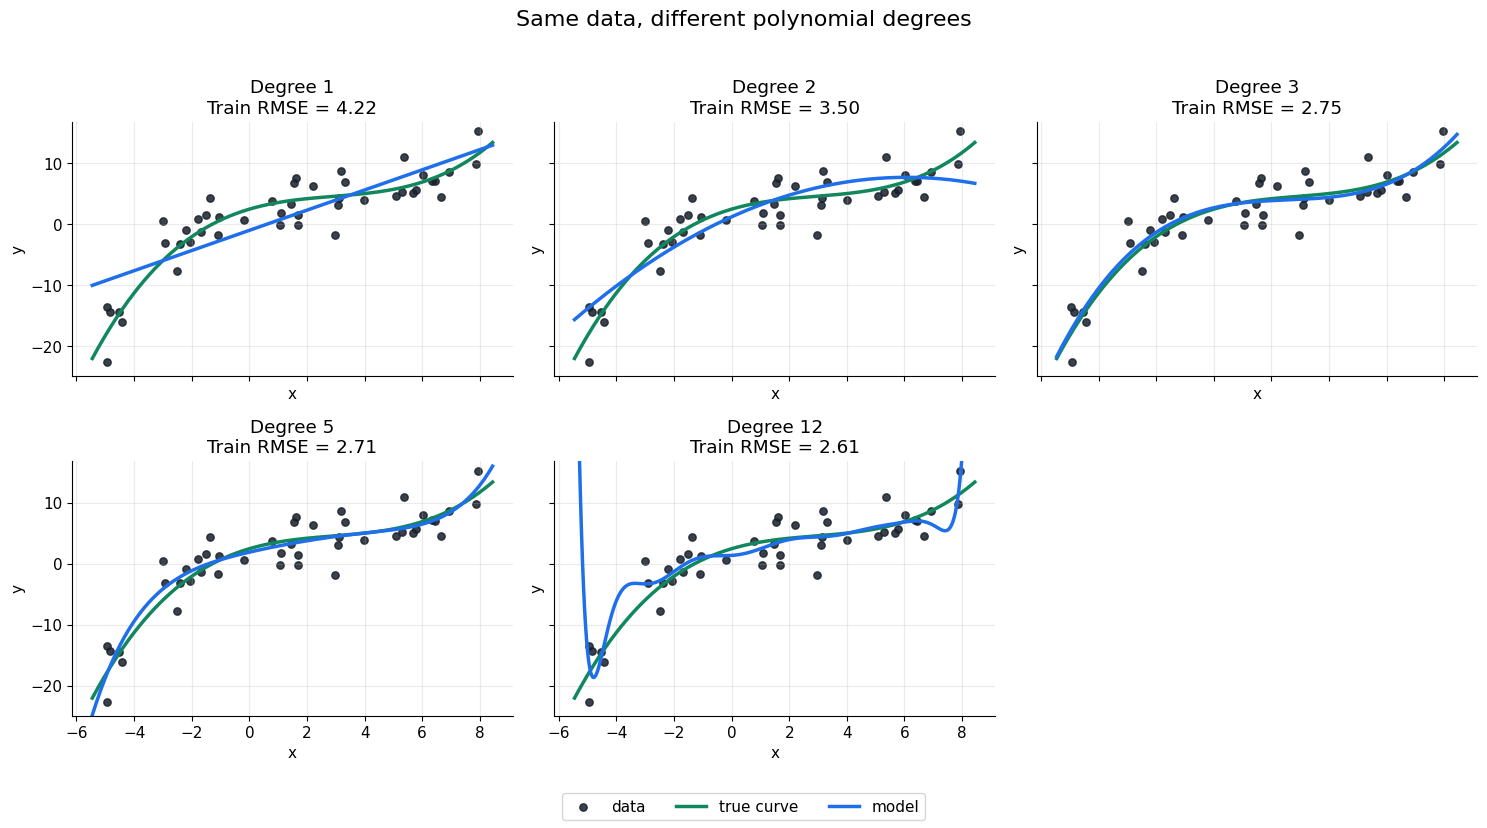

In [ ]:
degrees = [1, 2, 3, 5, 12]
x_grid = np.linspace(X.min() - 0.5, X.max() + 0.5, 400).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

# Determine appropriate y-limits based on data and true curve
y_min_overall = min(y.min(), true_curve(x_grid[:, 0]).min()) * 1.1
y_max_overall = max(y.max(), true_curve(x_grid[:, 0]).max()) * 1.1

for ax, degree in zip(axes, degrees):
    model = polynomial_model(degree)
    model.fit(X, y)

    y_pred_grid = model.predict(x_grid)
    y_pred_train = model.predict(X)

    ax.scatter(X[:, 0], y, color="#18202a", s=28, alpha=0.85, label="data")
    ax.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=2.5, label="true curve")
    ax.plot(x_grid[:, 0], y_pred_grid, color="#1f6feb", linewidth=2.5, label="model")
    ax.set_title(f"Degree {degree}\nTrain RMSE = {rmse(y, y_pred_train):.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylim(y_min_overall, y_max_overall) # Set y-axis limits

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
fig.suptitle("Same data, different polynomial degrees", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [ ]:
small_x = np.array([[1], [2], [3], [4], [5]])
poly = PolynomialFeatures(degree=10, include_bias=False)
poly_matrix = poly.fit_transform(x_grid)
pd.DataFrame(poly_matrix, columns=poly.get_feature_names_out(["x"]))

,x,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10
0,-5.451455,29.718360,-162.008298,883.180922,-4814.620924,26246.688605,-1.430826e+05,7.800085e+05,-4.252181e+06,2.318057e+07
1,-5.416635,29.339939,-158.923753,860.832029,-4662.813250,25256.759351,-1.368067e+05,7.410318e+05,-4.013899e+06,2.174183e+07
2,-5.381816,28.963943,-155.878611,838.909998,-4514.859218,24298.141413,-1.307681e+05,7.037700e+05,-3.787561e+06,2.038395e+07
3,-5.346997,28.590372,-152.872618,817.409358,-4370.684991,23370.037428,-1.249595e+05,6.681581e+05,-3.572639e+06,1.910289e+07
4,-5.312177,28.219225,-149.905521,796.324674,-4230.217678,22471.665364,-1.193735e+05,6.341330e+05,-3.368627e+06,1.789474e+07
...,...,...,...,...,...,...,...,...,...,...
395,8.302226,68.926955,572.247151,4750.925122,39443.253620,327466.801977,2.718703e+06,2.257129e+07,1.873919e+08,1.555770e+09
396,8.337045,69.506325,579.477385,4831.129238,40277.343546,335794.039715,2.799530e+06,2.333981e+07,1.945851e+08,1.622264e+09
397,8.371865,70.088120,586.768266,4912.344585,41125.484690,344296.997445,2.882408e+06,2.413113e+07,2.020226e+08,1.691305e+09
398,8.406684,70.672340,594.120046,4994.579628,41987.853841,352978.629140,2.967380e+06,2.494583e+07,2.097117e+08,1.762980e+09


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)


In [ ]:
rows = []
for degree in range(1, 16):
    model = polynomial_model(degree)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    rows.append({
        "degree": degree,
        "train_RMSE": rmse(y_train, train_pred),
        "test_RMSE": rmse(y_test, test_pred),
        "test_R2": r2_score(y_test, test_pred),
    })

results = pd.DataFrame(rows)
results.head(15)

,degree,train_RMSE,test_RMSE,test_R2
0,1,4.431733,3.794533,0.758365
1,2,3.707123,3.074687,0.841348
2,3,2.745627,2.881207,0.860687
3,4,2.732065,3.021442,0.846795
4,5,2.686817,3.065975,0.842246
5,6,2.671955,3.341582,0.812610
6,7,2.659477,3.579072,0.785027
7,8,2.655269,3.937511,0.739812
8,9,2.642493,4.404263,0.674471
9,10,2.641579,4.337954,0.684199


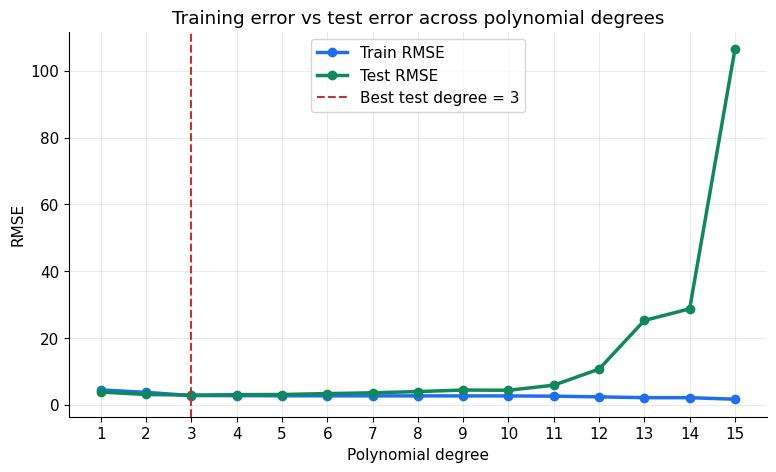

In [ ]:
best_degree_test = int(results.loc[results["test_RMSE"].idxmin(), "degree"])

plt.figure(figsize=(9, 5))
plt.plot(results["degree"], results["train_RMSE"], marker="o", linewidth=2.5, label="Train RMSE", color="#1f6feb")
plt.plot(results["degree"], results["test_RMSE"], marker="o", linewidth=2.5, label="Test RMSE", color="#11875d")
plt.axvline(best_degree_test, color="#c3342f", linestyle="--", label=f"Best test degree = {best_degree_test}")
plt.title("Training error vs test error across polynomial degrees")
plt.xlabel("Polynomial degree")
plt.ylabel("RMSE")
plt.xticks(results["degree"])
plt.legend()
plt.show()

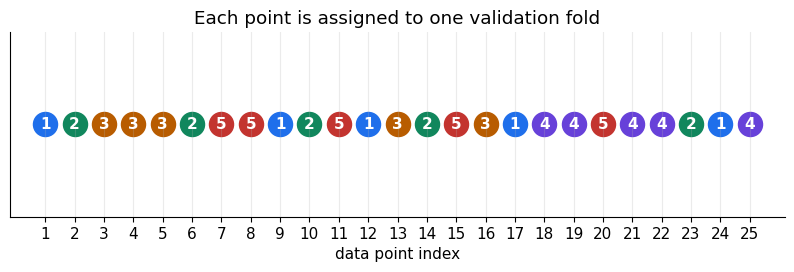

In [ ]:
n_points = 25
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_map = np.empty(n_points, dtype=int)

for fold_id, (_, val_idx) in enumerate(kf.split(np.arange(n_points)), start=1):
    fold_map[val_idx] = fold_id

plt.figure(figsize=(10, 2.4))
colors = ["#1f6feb", "#11875d", "#b85c00", "#6741d9", "#c3342f"]
for i, fold in enumerate(fold_map):
    plt.scatter(i, 1, s=300, color=colors[fold-1])
    plt.text(i, 1, str(fold), color="white", ha="center", va="center", fontweight="bold")
plt.yticks([])
plt.xticks(range(n_points), range(1, n_points + 1))
plt.title("Each point is assigned to one validation fold")
plt.xlabel("data point index")
plt.show()

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for degree in range(1, 16):
    model = polynomial_model(degree)
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
    )
    cv_rows.append({
        "degree": degree,
        "train_RMSE_mean": -scores["train_score"].mean(),
        "cv_RMSE_mean": -scores["test_score"].mean(),
        "cv_RMSE_std": scores["test_score"].std(),
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

,degree,train_RMSE_mean,cv_RMSE_mean,cv_RMSE_std
0,1,4.187440,4.269176,1.016103
1,2,3.455116,3.805618,0.782641
2,3,2.703375,3.072526,0.445353
3,4,2.680368,3.209064,0.456785
4,5,2.648191,3.162503,0.490289
5,6,2.604765,3.297932,0.413635
6,7,2.589674,3.445291,0.398783
7,8,2.562063,3.469547,0.396783
8,9,2.540871,3.610756,0.531378
9,10,2.513129,3.737127,0.446582


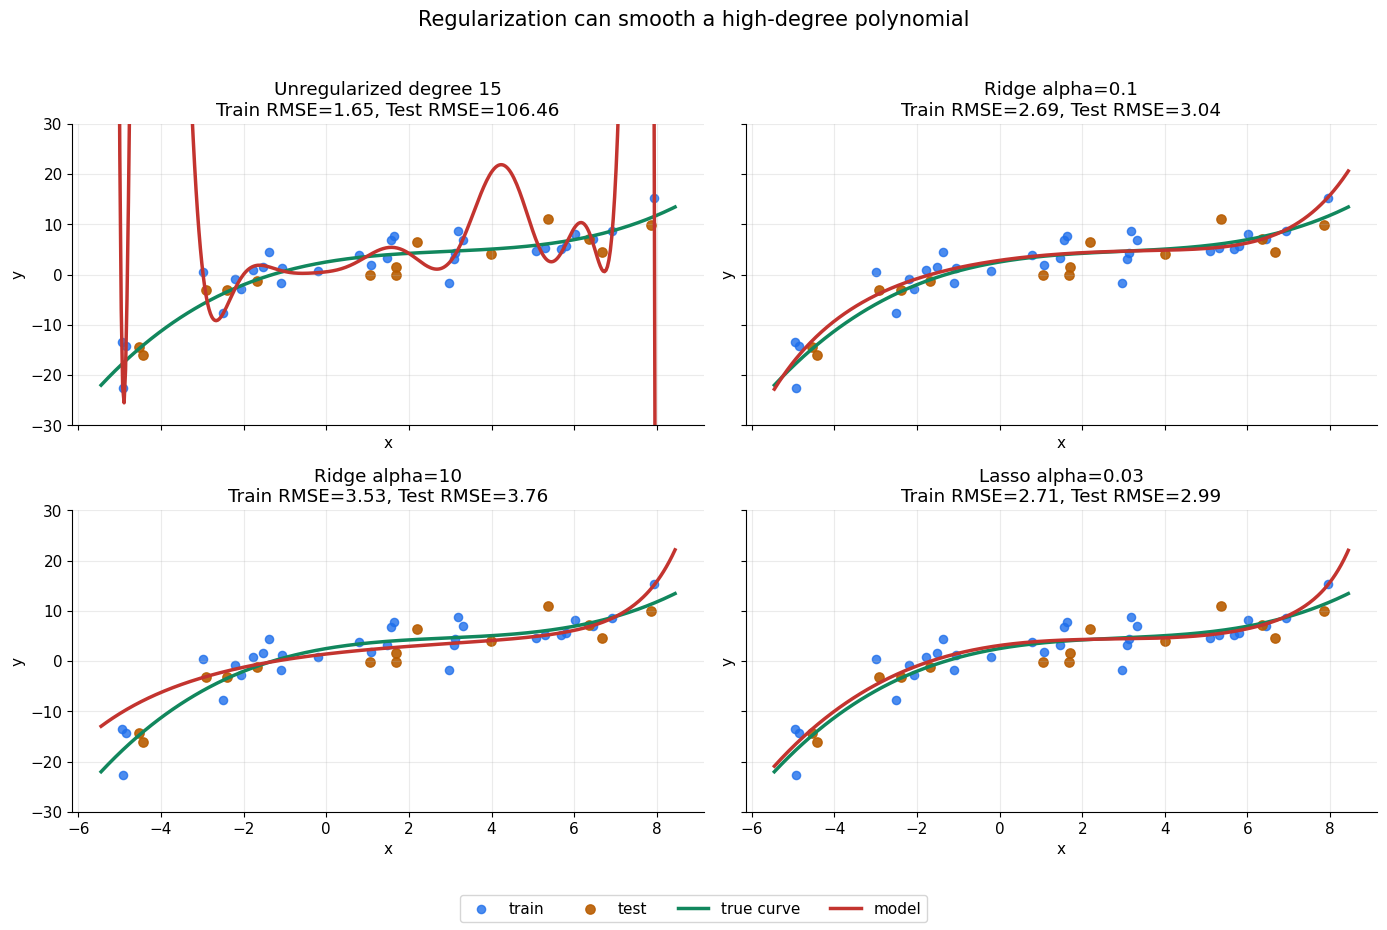

In [ ]:
high_degree = 15
models = {
    "Unregularized degree 15": polynomial_model(high_degree),
    "Ridge alpha=0.1": polynomial_model(high_degree, regularizer="ridge", alpha=0.1),
    "Ridge alpha=10": polynomial_model(high_degree, regularizer="ridge", alpha=10),
    "Lasso alpha=0.03": polynomial_model(high_degree, regularizer="lasso", alpha=0.03),
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.ravel()

# Define a reasonable y-axis range for better visualization of regularized models
y_min_limit = -30
y_max_limit = 30

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    pred_grid = model.predict(x_grid)
    train_error = rmse(y_train, model.predict(X_train))
    test_error = rmse(y_test, model.predict(X_test))

    ax.scatter(X_train[:, 0], y_train, color="#1f6feb", s=35, alpha=0.8, label="train")
    ax.scatter(X_test[:, 0], y_test, color="#b85c00", s=45, alpha=0.9, label="test")
    ax.plot(x_grid[:, 0], true_curve(x_grid[:, 0]), color="#11875d", linewidth=2.5, label="true curve")
    ax.plot(x_grid[:, 0], pred_grid, color="#c3342f", linewidth=2.5, label="model")
    ax.set_title(f"{name}\nTrain RMSE={train_error:.2f}, Test RMSE={test_error:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylim(y_min_limit, y_max_limit) # Apply the consistent y-axis limits

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("Regularization can smooth a high-degree polynomial", fontsize=15, y=1.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()